In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('../data/datacleaned/matches_cleaned.csv')
deliveries = pd.read_csv('../data/datacleaned/deliveries_final.csv')

print("Loaded successfully!")
print(matches.shape, deliveries.shape)

Loaded successfully!
(1090, 20) (260920, 19)


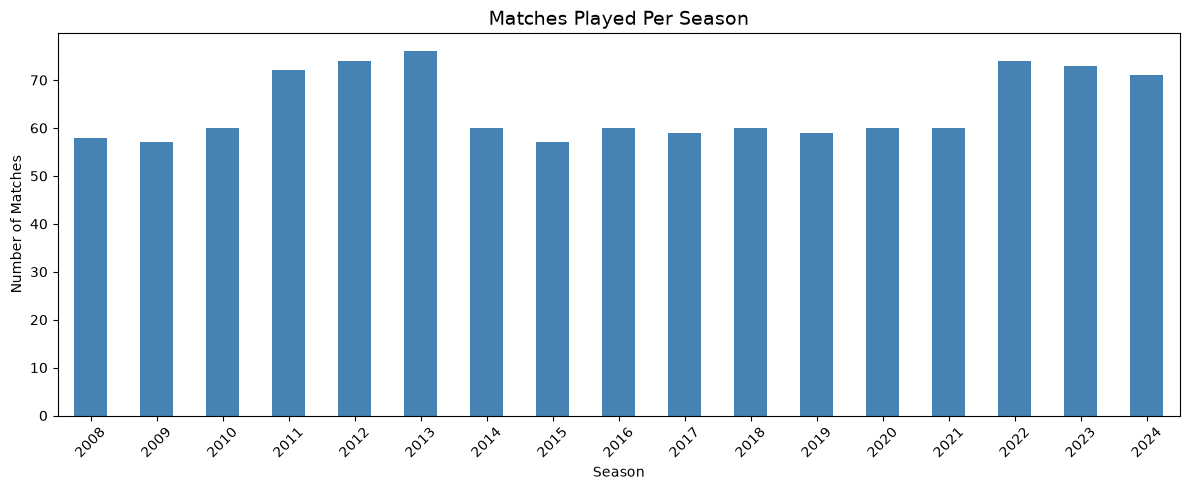

In [2]:
# Matches per season
plt.figure(figsize=(12,5))
matches['season'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Matches Played Per Season', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/matches_per_season.png')
plt.show()

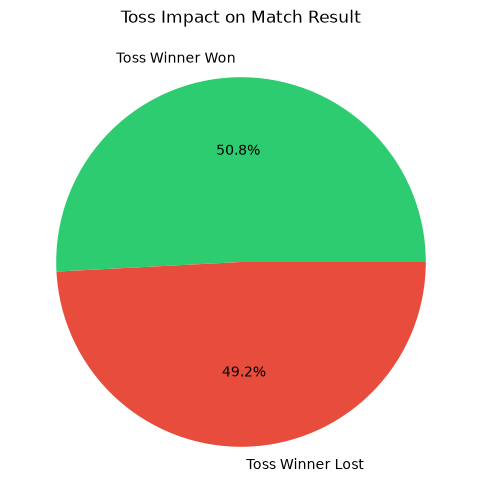

Toss winner won match: 50.83% of times


In [3]:
# Toss impact
toss_win = matches[matches['toss_winner'] == matches['winner']].shape[0]
toss_lose = matches[matches['toss_winner'] != matches['winner']].shape[0]

labels = ['Toss Winner Won', 'Toss Winner Lost']
values = [toss_win, toss_lose]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
plt.title('Toss Impact on Match Result')
plt.savefig('../visuals/toss_impact.png')
plt.show()

print(f"Toss winner won match: {toss_win/matches.shape[0]*100:.2f}% of times")

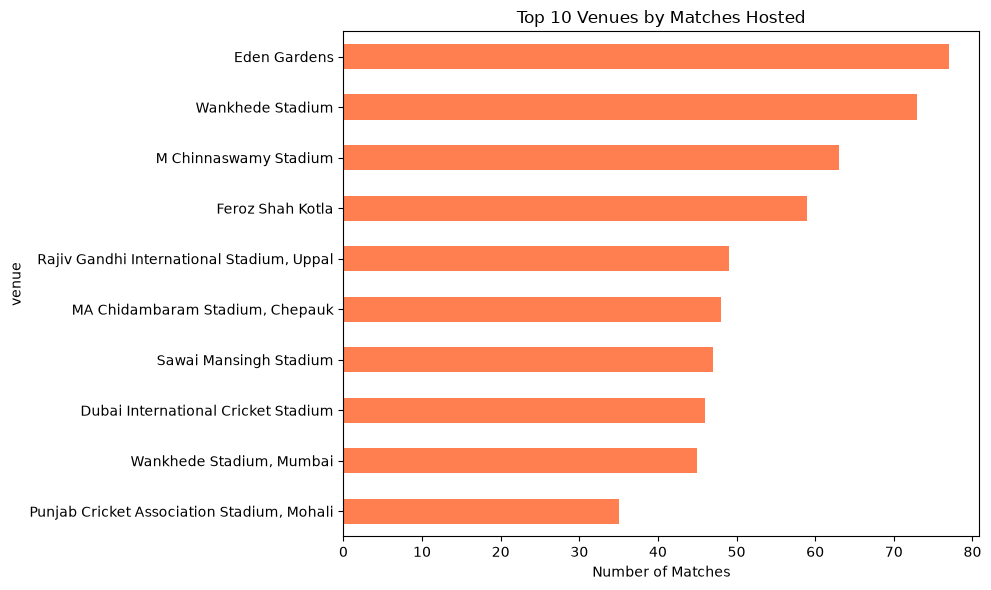

In [4]:
# Top 10 venues
plt.figure(figsize=(10,6))
matches['venue'].value_counts().head(10).sort_values().plot(
    kind='barh', color='coral'
)
plt.title('Top 10 Venues by Matches Hosted')
plt.xlabel('Number of Matches')
plt.tight_layout()
plt.savefig('../visuals/top_venues.png')
plt.show()

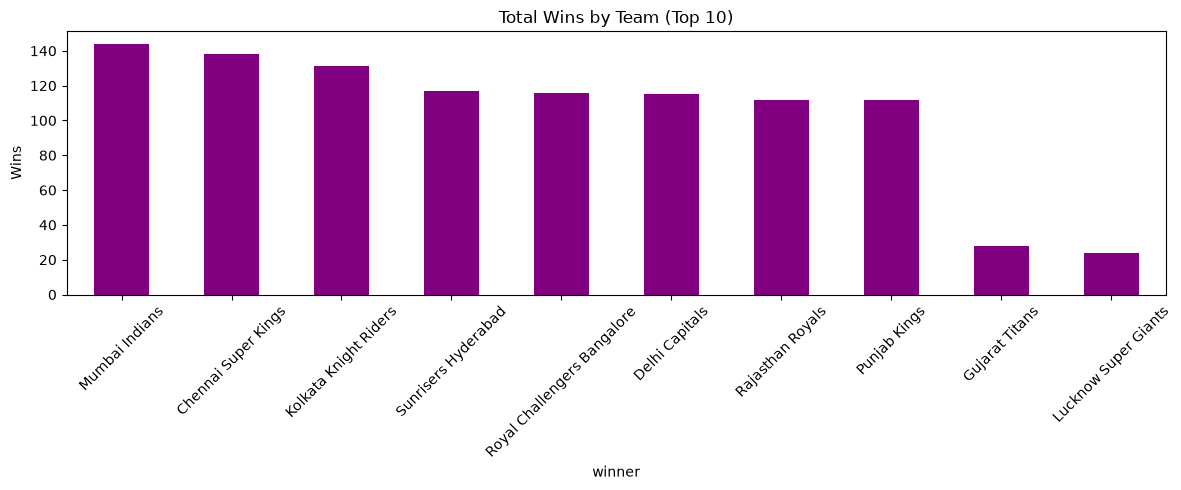

In [5]:
# Team wins bar chart
plt.figure(figsize=(12,5))
matches['winner'].value_counts().head(10).plot(kind='bar', color='purple')
plt.title('Total Wins by Team (Top 10)')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/team_wins.png')
plt.show()

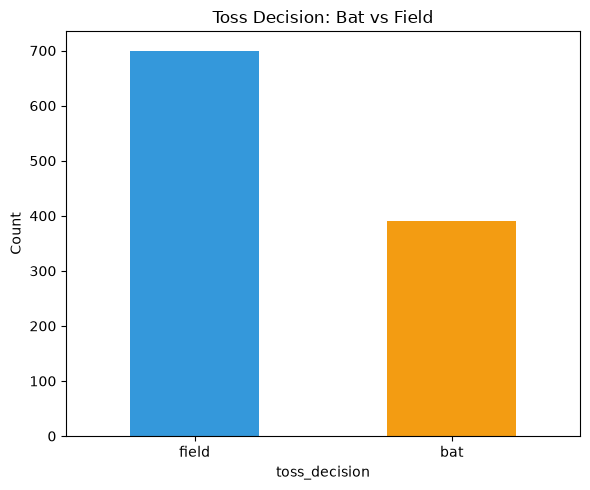

In [6]:
# Toss decision - bat vs field
plt.figure(figsize=(6,5))
matches['toss_decision'].value_counts().plot(kind='bar', color=['#3498db','#f39c12'])
plt.title('Toss Decision: Bat vs Field')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../visuals/toss_decision.png')
plt.show()

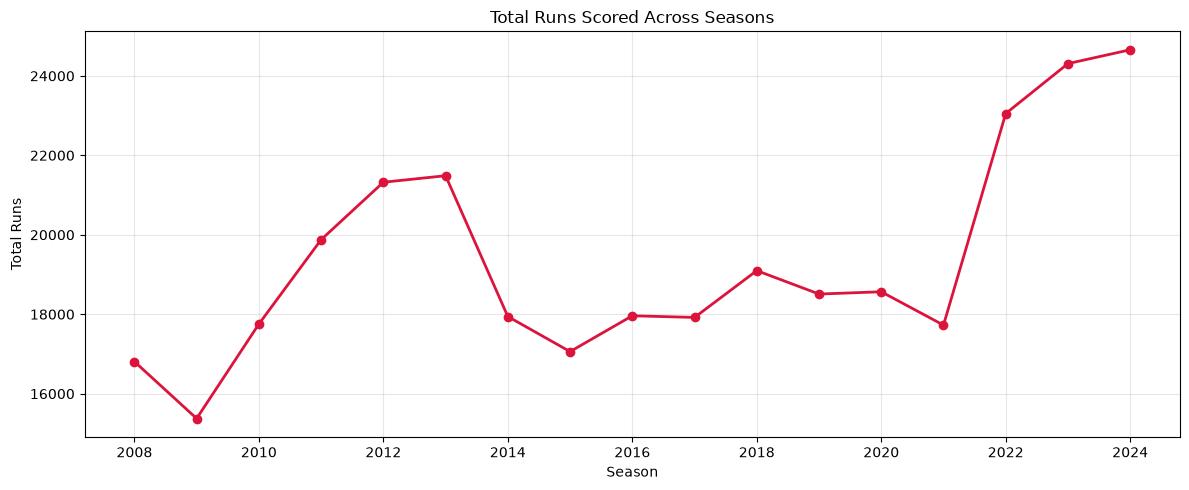

In [7]:
# Season trend - total runs
season_runs = deliveries.merge(
    matches[['id','season']], left_on='match_id', right_on='id'
)
season_trend = season_runs.groupby('season')['batsman_runs'].sum()

plt.figure(figsize=(12,5))
season_trend.plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title('Total Runs Scored Across Seasons')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visuals/season_trend.png')
plt.show()